# Analisis Descriptivo Univariado — Dataset PyMEs

**Fuente**: `data/ia_pymes.xlsx` (368 encuestas a dueños/as de pequeñas y medianas empresas)

**Objetivo (Pipeline Step 2)**: caracterizar la muestra y las respuestas mediante estadistica
descriptiva univariada — tablas de frecuencia, graficos de barras y analisis de valores
faltantes — como base para las etapas posteriores de cruces y modelamiento.

## Tabla de contenidos

1. [Notas de preparacion de datos](#1.-Notas-de-preparacion-de-datos)
2. [Resumen del dataset](#2.-Resumen-del-dataset)
3. [Perfil demografico](#3.-Perfil-demografico)
    - [3.1 Sexo](#3.1-Sexo)
    - [3.2 Rango etario (edad)](#3.2-Rango-etario-(edad))
    - [3.3 Nivel educacional (niveduc)](#3.3-Nivel-educacional-(niveduc))
    - [3.4 Ocupacion](#3.4-Ocupacion)
    - [3.5 Grupo socioeconomico (nse)](#3.5-Grupo-socioeconomico-(nse))
4. [Variables de respuesta del negocio](#4.-Variables-de-respuesta-del-negocio)
    - [4.1 p01 — Tarea que mas tiempo consume](#4.1-p01-—-Tarea-que-mas-tiempo-consume)
    - [4.2 p02 — Principal fuente de ayuda](#4.2-p02-—-Principal-fuente-de-ayuda)
    - [4.3 p03 — Barreras para crecer](#4.3-p03-—-Barreras-para-crecer)
    - [4.4 p04 — Tiempo semanal dispuesto a aprender](#4.4-p04-—-Tiempo-semanal-dispuesto-a-aprender)
5. [Analisis de valores faltantes](#5.-Analisis-de-valores-faltantes)
6. [Resumen de hallazgos clave](#6.-Resumen-de-hallazgos-clave)


## 1. Notas de preparacion de datos

Antes de este analisis se revisaron los helpers compartidos (`analysis_helpers.py`, entregable
del Step 1) y se corrigieron tres inconsistencias que habrian distorsionado las frecuencias de
`p03`/`p04` y el ordenamiento de `edad`/`niveduc`:

1. **Mapeo de columnas incompleto (`PYMES_CODES`)** — el libro `ia_pymes.xlsx` tiene 13 columnas
   (6 demograficas + 7 de respuesta: `p01`, `p01_otro`, `p02`, `p02_otro`, `p03`, `p03_otro`,
   `p04`), pero la lista original solo declaraba 11 codigos. Esto desplazaba el mapeo: la
   columna de "otro" de `p02` quedaba etiquetada como `p03`, la pregunta real de barreras
   ("¿Qué te frena...?") quedaba etiquetada como `p04`, y la pregunta de tiempo semanal quedaba
   sin mapear. Se agregaron `p02_otro` y `p03_otro` a `PYMES_CODES` para alinear el mapeo con el
   diccionario de columnas documentado en `CLAUDE.md`.
2. **`lowercase_df()` no normalizaba columnas de texto** — con pandas 3.0, `read_excel` infiere
   dtype `str` (no `object`) para columnas de texto, y la condicion original
   (`s.dtype == object`) las omitia silenciosamente. Se amplio la condicion con
   `pd.api.types.is_string_dtype(s.dtype)` para que `p01`–`p04` tambien queden en minusculas,
   consistente con el resto del pipeline.
3. **Categorias con guion mal normalizadas** — valores como `"[31 - 40]"` (con espacios) no
   calzaban con la categoria canonica `"[31-40]"`, dejando `edad` practicamente sin orden logico.
   Se agrego un paso de normalizacion de guiones en `normalize_text()`.
4. **`niveduc` con niveles no documentados** — la muestra incluye "basica incompleta/completa"
   y "postgrado", ausentes del orden canonico original. Al ser extremos inequivocos (por debajo
   de "media" y por encima de "universitaria completa" respectivamente), se agregaron a
   `CATEGORY_ORDERS["niveduc"]`.

`ocupacion` tambien contiene 3 categorias fuera del orden canonico (`alto(a) ejecutivo(a)`,
`ejecutivo(a) medio(a) / profesional independiente`, `trabajos menores e informales`) cuya
posicion jerarquica es ambigua sin definicion de negocio; se dejan intencionalmente sin ordenar
y se documentan como hallazgo de calidad de datos en la Seccion 3.4, en vez de asumir un orden.


In [1]:
from analysis_helpers import *
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

dfpymes = load_survey(PYMES_PATH, PYMES_CODES, dataset="pymes")
set_theme("light")


Rename map (raw header -> code):
  id         <- 'ID'
  sexo       <- 'SEXO'
  edad       <- 'RANGO ETARIO'
  niveduc    <- '¿NIVEL EDUCACIONAL?'
  ocupacion  <- '¿TIPO DE TRABAJO?'
  nse        <- 'GRUPO NSE'
  p01        <- 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)'
  p01_otro   <- 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))'
  p02        <- 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)'
  p02_otro   <- 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))'
  p03        <- '¿Qué te frena hoy para hacer crecer tu negocio? (Total)'
  p03_otro   <- '¿Qué te frena hoy para hacer crecer

/Users/tomas/github/icd_ia/analysis_helpers.py:354: UserWarning: Column 'ocupacion' has 3 value(s) outside the canonical ordering: ['alto(a) ejecutivo(a)', 'ejecutivo(a) medio(a) / profesional independiente', 'trabajos menores e informales'] -- appended as trailing categories.
  df = apply_categoricals(df, strict=strict, verbose=verbose)


<module 'matplotlib.pyplot' from '/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/matplotlib/pyplot.py'>

## 2. Resumen del dataset

Vista general de columnas, tipos de dato y completitud antes de entrar al detalle
variable por variable.

In [2]:
labeled_info(dfpymes)

,code,label,dtype,n_valid,n_missing,pct_missing,n_unique
0,id,ID,int64,368,0,0.0,368
1,sexo,SEXO,category,368,0,0.0,2
2,edad,RANGO ETARIO,category,368,0,0.0,5
3,niveduc,¿NIVEL EDUCACIONAL?,category,368,0,0.0,9
4,ocupacion,¿TIPO DE TRABAJO?,category,368,0,0.0,10
5,nse,GRUPO NSE,category,368,0,0.0,4
6,p01,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",str,368,0,0.0,5
7,p01_otro,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",float64,0,368,100.0,0
8,p02,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",str,368,0,0.0,5
9,p02_otro,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",float64,0,368,100.0,0


In [3]:
labeled_head(dfpymes, 5)

,id\nID,sexo\nSEXO,edad\nRANGO ETARIO,niveduc\n¿NIVEL EDUCACIONAL?,ocupacion\n¿TIPO DE TRABAJO?,nse\nGRUPO NSE,"p01\nDe las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)","p01_otro\nDe las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))","p02\nCuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)","p02_otro\nCuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))",p03\n¿Qué te frena hoy para hacer crecer tu negocio? (Total),p03_otro\n¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),"p04\nSi una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?"
0,1,masculino,[51-60],media completa,jubilado(a),d+e,llevar contabilidad,NaN,familia o amigos,NaN,falta de capital,NaN,1 a 2 horas
1,2,femenino,[51-60],tecnica superior completa,estudiante,c3,atender clientes,NaN,redes sociales / internet,NaN,falta de capital,NaN,1 a 2 horas
2,3,masculino,[41-50],universitaria completa,ejecutivo(a) medio(a) / profesional independiente,abc1,hacer publicidad,NaN,familia o amigos,NaN,falta de capital,NaN,más de 4 horas
3,4,femenino,[31-40],tecnica superior incompleta,dueño(a) de casa,c3,llevar contabilidad,NaN,familia o amigos,NaN,falta de capital,NaN,1 hora o menos
4,5,masculino,[18-30],universitaria completa,empleado(a) administrativo(a) / tecnico,abc1,atender clientes,NaN,nadie / lo resuelvo solo,NaN,falta de capital,NaN,más de 4 horas


### Interpretacion — Resumen del dataset (Hallazgo 1)

El dataset tiene **368 respuestas y 13 columnas**: 5 variables demograficas (`sexo`, `edad`,
`niveduc`, `ocupacion`, `nse`), 4 preguntas cerradas de negocio (`p01`–`p04`) y 3 campos de
texto libre "otro" (`p01_otro`, `p02_otro`, `p03_otro`). Las 9 variables categoricas principales
tienen **0% de valores faltantes** — cobertura completa para el analisis univariado. Los 3
campos "otro" estan **100% vacios** (ver Seccion 5): ningun respondente selecciono la opcion
abierta, por lo que no aportan senal adicional en este dataset.

## 3. Perfil demografico

### 3.1 Sexo

In [4]:
tbl_sexo = labeled_value_counts_detailed(dfpymes, "sexo")
tbl_sexo

sexo - SEXO   (n = 368)
------------------------------------------------------------------------
  femenino                             192   52.2%  ##############################
  masculino                            176   47.8%  ############################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,femenino,192,52.2,52.2,52.2
1,masculino,176,47.8,47.8,100.0


findfont: Failed to find font weight semibold, now using 700.


'/Users/tomas/github/icd_ia/figures/pymes/pymes_sexo_bar.png'

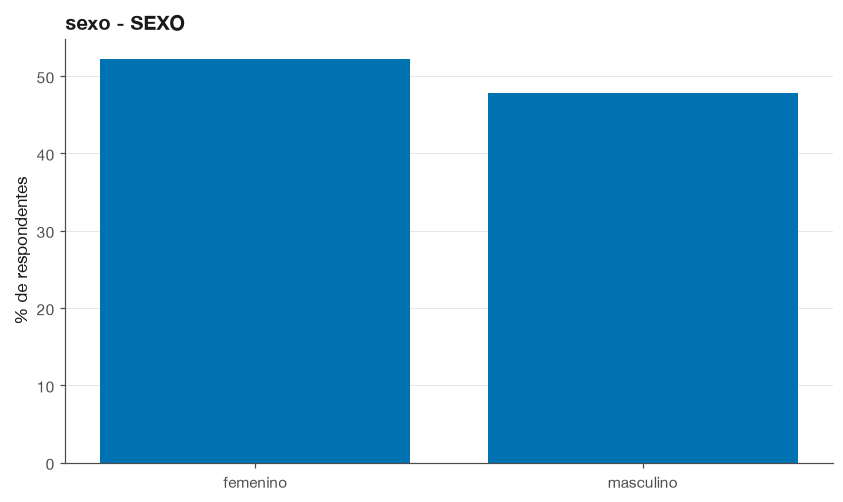

In [5]:
ax = bar_freq(dfpymes, "sexo", horizontal=False)
save_fig(ax, "pymes_sexo_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 2):** la muestra esta **casi equilibrada por genero**
(52.2% femenino vs. 47.8% masculino, 192 vs. 176 respondentes), sin sesgo relevante que
condicione las comparaciones por sexo en etapas posteriores.

### 3.2 Rango etario (edad)

In [6]:
tbl_edad = labeled_value_counts_detailed(dfpymes, "edad")
tbl_edad

edad - RANGO ETARIO   (n = 368)
------------------------------------------------------------------------
  [18-30]                               55   14.9%  ###################
  [31-40]                               75   20.4%  ##########################
  [41-50]                               86   23.4%  ##############################
  [51-60]                               79   21.5%  ############################
  [61+]                                 73   19.8%  #########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,[18-30],55,14.9,14.9,14.9
1,[31-40],75,20.4,20.4,35.3
2,[41-50],86,23.4,23.4,58.7
3,[51-60],79,21.5,21.5,80.2
4,[61+],73,19.8,19.8,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_edad_bar.png'

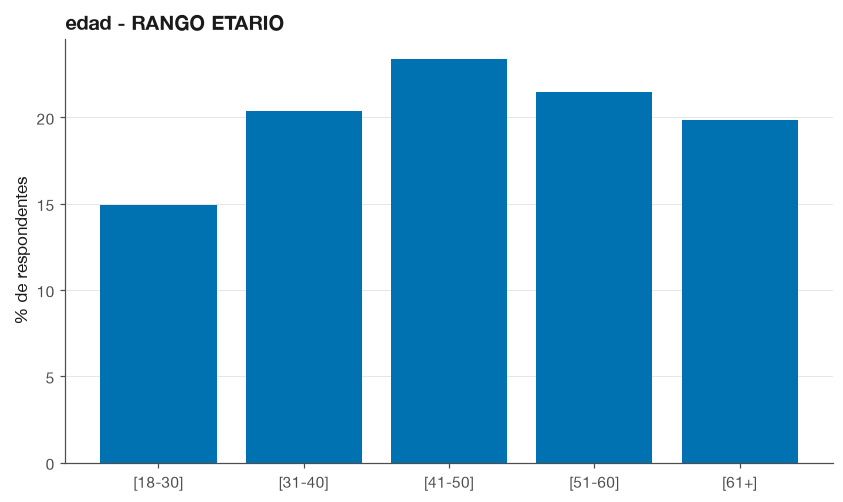

In [7]:
ax = bar_freq(dfpymes, "edad", horizontal=False)
save_fig(ax, "pymes_edad_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 3):** la edad **se concentra en tramos medios y altos**: los
grupos `[41-50]` (23.4%) y `[51-60]` (21.5%) son los mas numerosos, y sumando `[61+]` (19.8%)
el **64.7% de los dueños/as de PyMEs tiene 41 años o mas**. El tramo joven `[18-30]` es el
menos representado (14.9%), lo que sugiere que el emprendimiento PyME en esta muestra es
mayoritariamente una actividad de adultos de mediana edad y mayores, no de emprendedores
jovenes.

### 3.3 Nivel educacional (niveduc)

In [8]:
tbl_niveduc = labeled_value_counts_detailed(dfpymes, "niveduc")
tbl_niveduc

niveduc - ¿NIVEL EDUCACIONAL?   (n = 368)
------------------------------------------------------------------------
  basica incompleta                      1    0.3%  
  basica completa                        4    1.1%  #
  media incompleta                       6    1.6%  ##
  media completa                        97   26.4%  ##############################
  tecnica superior incompleta           41   11.1%  #############
  tecnica superior completa             79   21.5%  ########################
  universitaria incompleta              47   12.8%  ###############
  universitaria completa                83   22.6%  ##########################
  postgrado                             10    2.7%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,basica incompleta,1,0.3,0.3,0.3
1,basica completa,4,1.1,1.1,1.4
2,media incompleta,6,1.6,1.6,3.0
3,media completa,97,26.4,26.4,29.4
4,tecnica superior incompleta,41,11.1,11.1,40.5
5,tecnica superior completa,79,21.5,21.5,62.0
6,universitaria incompleta,47,12.8,12.8,74.8
7,universitaria completa,83,22.6,22.6,97.4
8,postgrado,10,2.7,2.7,100.1


'/Users/tomas/github/icd_ia/figures/pymes/pymes_niveduc_bar.png'

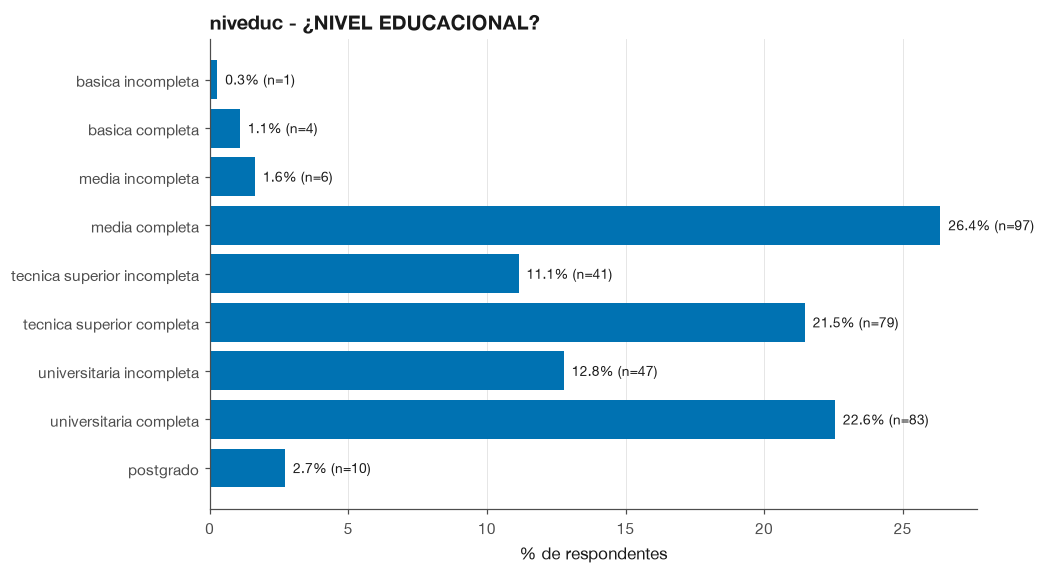

In [9]:
ax = bar_freq(dfpymes, "niveduc", horizontal=True)
save_fig(ax, "pymes_niveduc_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 4):** el nivel educacional es **heterogeneo pero con clara
mayoria post-secundaria**: sumando tecnica superior (completa+incompleta, 32.6%) y
universitaria (completa+incompleta, 35.4%), el **70.7% de la muestra tiene formacion
post-secundaria**, aunque gran parte incompleta. La educacion basica es marginal (1.4%
combinado) y el postgrado es minoritario (2.7%). Esto contradice la percepcion habitual de
que las/os dueñas/os de PyMEs tienen bajo nivel educativo formal: en esta muestra predomina
la educacion media completa (26.4%) y superior, no la basica.

### 3.4 Ocupacion

In [10]:
tbl_ocupacion = labeled_value_counts_detailed(dfpymes, "ocupacion")
tbl_ocupacion

ocupacion - ¿TIPO DE TRABAJO?   (n = 368)
------------------------------------------------------------------------
  cesante                               25    6.8%  ##########
  estudiante                            21    5.7%  ########
  dueño(a) de casa                      32    8.7%  ############
  jubilado(a)                           36    9.8%  ##############
  oficio menor                          20    5.4%  ########
  oficio calificado                     31    8.4%  ############
  empleado(a) administrativo(a) /       77   20.9%  ##############################
  alto(a) ejecutivo(a)                  13    3.5%  #####
  ejecutivo(a) medio(a) / profesio      54   14.7%  #####################
  trabajos menores e informales         59   16.0%  #######################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,cesante,25,6.8,6.8,6.8
1,estudiante,21,5.7,5.7,12.5
2,dueño(a) de casa,32,8.7,8.7,21.2
3,jubilado(a),36,9.8,9.8,31.0
4,oficio menor,20,5.4,5.4,36.4
5,oficio calificado,31,8.4,8.4,44.8
6,empleado(a) administrativo(a) / tecnico,77,20.9,20.9,65.7
7,alto(a) ejecutivo(a),13,3.5,3.5,69.2
8,ejecutivo(a) medio(a) / profesional independiente,54,14.7,14.7,83.9
9,trabajos menores e informales,59,16.0,16.0,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_ocupacion_bar.png'

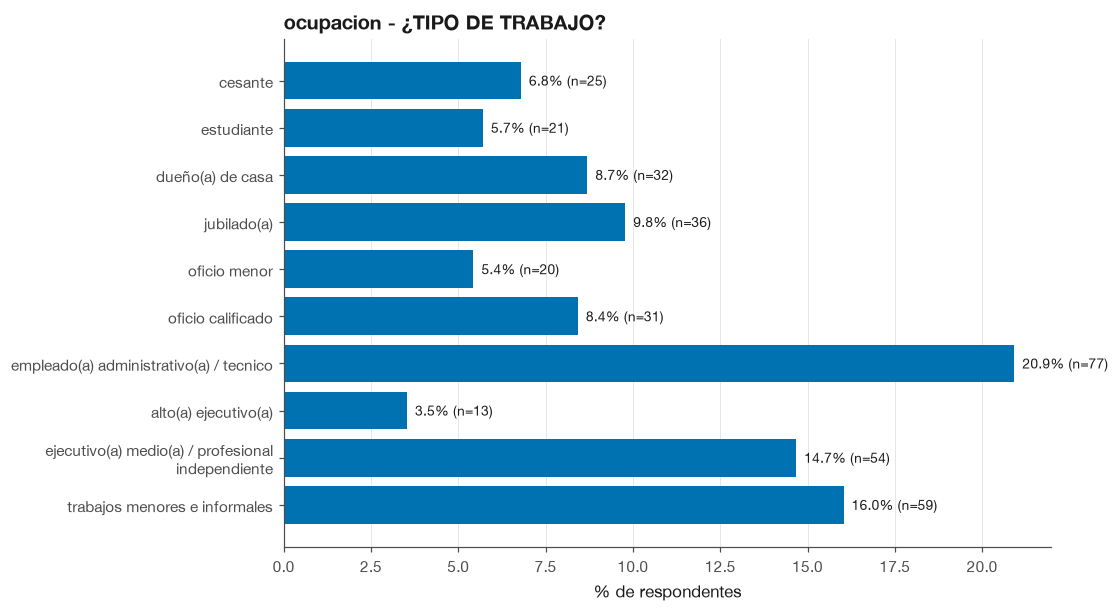

In [11]:
ax = bar_freq(dfpymes, "ocupacion", horizontal=True)
save_fig(ax, "pymes_ocupacion_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 5):** la categoria mas frecuente es "empleado(a)
administrativo(a) / tecnico" (20.9%), seguida de "trabajos menores e informales" (16.0%) y
"ejecutivo(a) medio(a) / profesional independiente" (14.7%) — es decir, muchas/os dueñas/os de
PyME combinan el negocio con otra ocupacion declarada, desde trabajo informal hasta roles
profesionales. **Nota de calidad de datos:** las 3 categorias mencionadas junto con
"alto(a) ejecutivo(a)" (3.5%) no forman parte del orden jerarquico documentado en
`CLAUDE.md`/`CATEGORY_ORDERS`, por lo que quedan como categorias adicionales sin una posicion
jerarquica definida (ver Seccion 1). Cualquier analisis ordinal de `ocupacion` en etapas
posteriores deberia primero decidir, junto al equipo de negocio, donde ubicar estos 3 niveles
antes de tratarlos como una escala.

### 3.5 Grupo socioeconomico (nse)

In [12]:
tbl_nse = labeled_value_counts_detailed(dfpymes, "nse")
tbl_nse

nse - GRUPO NSE   (n = 368)
------------------------------------------------------------------------
  d+e                                   66   17.9%  ###############
  c3                                   122   33.2%  ############################
  c2                                   131   35.6%  ##############################
  abc1                                  49   13.3%  ###########
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,d+e,66,17.9,17.9,17.9
1,c3,122,33.2,33.2,51.1
2,c2,131,35.6,35.6,86.7
3,abc1,49,13.3,13.3,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_nse_bar.png'

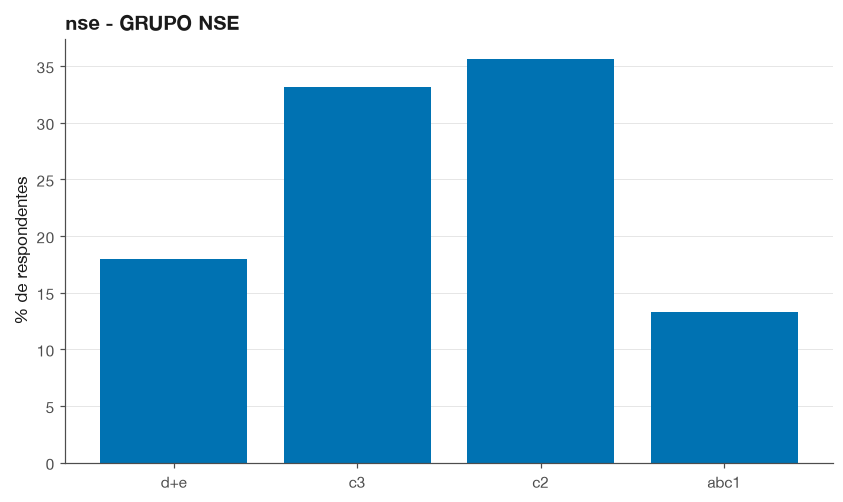

In [13]:
ax = bar_freq(dfpymes, "nse", horizontal=False)
save_fig(ax, "pymes_nse_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 6):** el grupo socioeconomico esta **concentrado en el
segmento medio** (c3 33.2% + c2 35.6% = 68.8%), con menor representacion de los extremos
(d+e 17.9%, abc1 13.3%). No hay valores faltantes en `nse` para este dataset (a diferencia del
dataset de competentes, donde si se observa 1 caso sin dato).

## 4. Variables de respuesta del negocio

### 4.1 p01 — Tarea que mas tiempo consume

In [14]:
tbl_p01 = labeled_value_counts_detailed(dfpymes, "p01")
tbl_p01

p01 - De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)   (n = 368)
------------------------------------------------------------------------
  llevar contabilidad                   59   16.0%  ##################
  atender clientes                     100   27.2%  ##############################
  hacer publicidad                      94   25.5%  ############################
  ninguna me quita tiempo / no apl      55   14.9%  ################
  controlar inventario                  60   16.3%  ##################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,llevar contabilidad,59,16.0,16.0,16.0
1,atender clientes,100,27.2,27.2,43.2
2,hacer publicidad,94,25.5,25.5,68.7
3,ninguna me quita tiempo / no aplica,55,14.9,14.9,83.6
4,controlar inventario,60,16.3,16.3,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p01_bar.png'

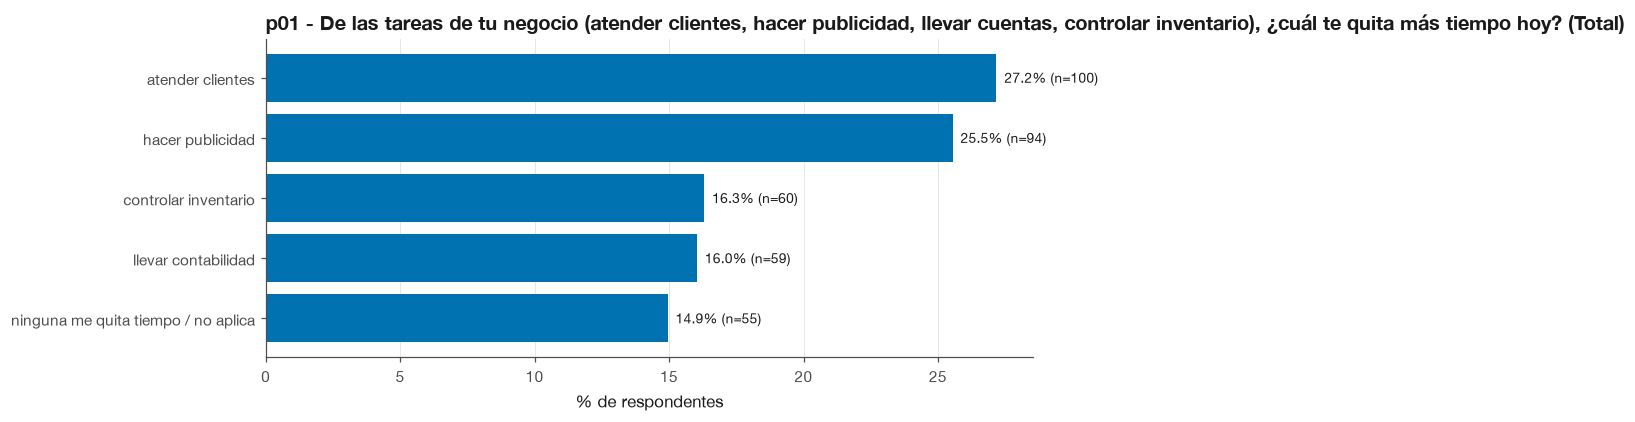

In [15]:
ax = bar_freq(dfpymes, "p01", horizontal=True)
save_fig(ax, "pymes_p01_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 7):** no hay una tarea claramente dominante: "atender
clientes" (27.2%) y "hacer publicidad" (25.5%) concentran mas de la mitad de las respuestas,
seguidas por "controlar inventario" (16.3%) y "llevar contabilidad" (16.0%) en niveles
similares. Un 14.9% declara que "ninguna" tarea le quita tiempo. La distribucion relativamente
pareja sugiere que **no existe un unico cuello de botella operativo** en el negocio promedio;
soluciones digitales dirigidas a una sola tarea (p.ej. solo contabilidad) dejarian fuera a la
mayoria de la demanda.

### 4.2 p02 — Principal fuente de ayuda

In [16]:
tbl_p02 = labeled_value_counts_detailed(dfpymes, "p02")
tbl_p02

p02 - Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)   (n = 368)
------------------------------------------------------------------------
  familia o amigos                     189   51.4%  ##############################
  redes sociales / internet             78   21.2%  ############
  nadie / lo resuelvo solo              47   12.8%  #######
  un curso o capacitación               38   10.3%  ######
  sercotec u otra institución públ      16    4.3%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,familia o amigos,189,51.4,51.4,51.4
1,redes sociales / internet,78,21.2,21.2,72.6
2,nadie / lo resuelvo solo,47,12.8,12.8,85.4
3,un curso o capacitación,38,10.3,10.3,95.7
4,sercotec u otra institución pública,16,4.3,4.3,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p02_bar.png'

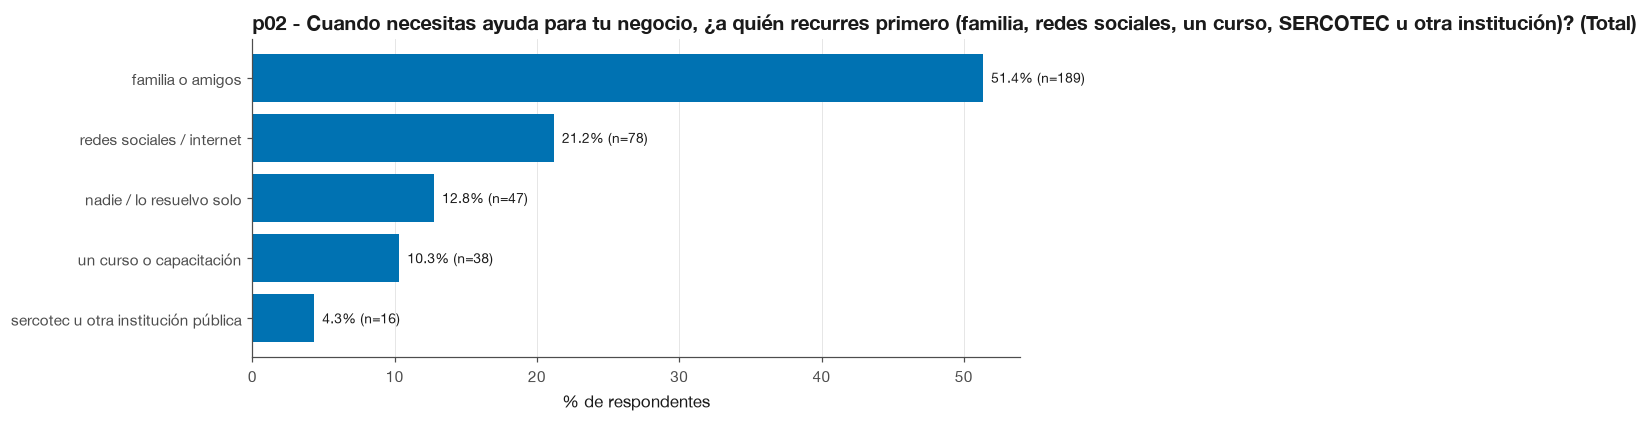

In [17]:
ax = bar_freq(dfpymes, "p02", horizontal=True)
save_fig(ax, "pymes_p02_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 8):** la fuente de ayuda **claramente dominante es
"familia o amigos"** (51.4%, mas de la mitad de la muestra), seguida por "redes
sociales / internet" (21.2%). El apoyo institucional formal es marginal: "un curso o
capacitacion" (10.3%) y especialmente "SERCOTEC u otra institucion publica" (solo 4.3%). Este
patron revela una **brecha de alcance institucional**: los canales formales de apoyo al
emprendimiento llegan a una fraccion muy pequeña de la muestra, mientras que la red social
informal absorbe la mayor parte de la demanda de ayuda.

### 4.3 p03 — Barreras para crecer

In [18]:
tbl_p03 = labeled_value_counts_detailed(dfpymes, "p03")
tbl_p03

p03 - ¿Qué te frena hoy para hacer crecer tu negocio? (Total)   (n = 368)
------------------------------------------------------------------------
  falta de capital                     222   60.3%  ##############################
  falta de conocimiento                 28    7.6%  ####
  falta de clientes                     53   14.4%  #######
  falta de tiempo                       43   11.7%  ######
  nada me frena                         22    6.0%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,falta de capital,222,60.3,60.3,60.3
1,falta de conocimiento,28,7.6,7.6,67.9
2,falta de clientes,53,14.4,14.4,82.3
3,falta de tiempo,43,11.7,11.7,94.0
4,nada me frena,22,6.0,6.0,100.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p03_bar.png'

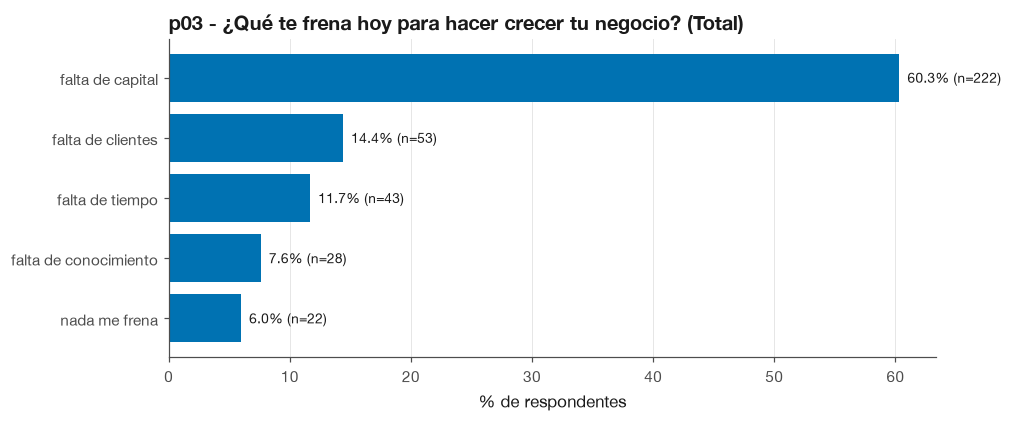

In [19]:
ax = bar_freq(dfpymes, "p03", horizontal=True)
save_fig(ax, "pymes_p03_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 9):** "falta de capital" es, por lejos, **la barrera mas
citada** (60.3%, mas del doble que la suma de las siguientes dos categorias). Le siguen "falta
de clientes" (14.4%) y "falta de tiempo" (11.7%), mientras que "falta de conocimiento" (7.6%) y
"nada me frena" (6.0%) son minoritarias. Esto es relevante para el diseño de intervenciones:
**las herramientas digitales por si solas no resuelven la barrera principal declarada** (acceso
a capital), aunque si podrian aportar a barreras secundarias como captacion de clientes o
gestion eficiente del tiempo.

### 4.4 p04 — Tiempo semanal dispuesto a aprender

In [20]:
tbl_p04 = labeled_value_counts_detailed(dfpymes, "p04")
tbl_p04

p04 - Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?   (n = 368)
------------------------------------------------------------------------
  1 a 2 horas                          106   28.8%  ##############################
  más de 4 horas                        88   23.9%  #########################
  1 hora o menos                        59   16.0%  #################
  no estoy dispuesto a dedicar tie      21    5.7%  ######
  2 a 4 horas                           94   25.5%  ###########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,1 a 2 horas,106,28.8,28.8,28.8
1,más de 4 horas,88,23.9,23.9,52.7
2,1 hora o menos,59,16.0,16.0,68.7
3,no estoy dispuesto a dedicar tiempo,21,5.7,5.7,74.4
4,2 a 4 horas,94,25.5,25.5,99.9


'/Users/tomas/github/icd_ia/figures/pymes/pymes_p04_bar.png'

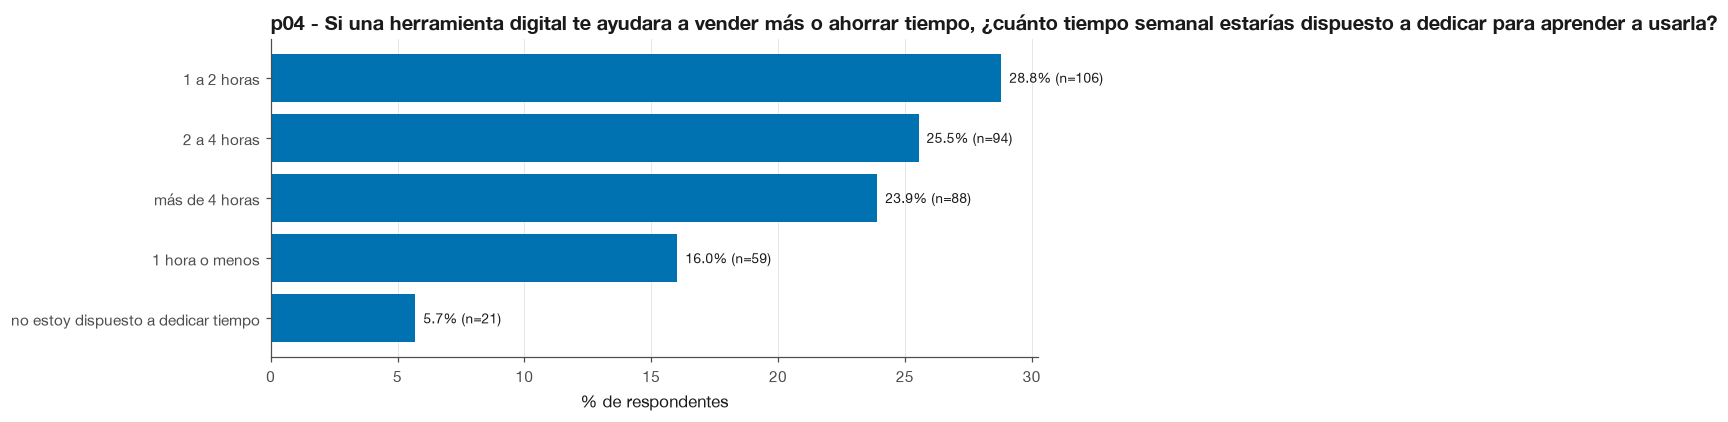

In [21]:
ax = bar_freq(dfpymes, "p04", horizontal=True)
save_fig(ax, "pymes_p04_bar.png", subdir="pymes")

**Interpretacion (Hallazgo 10):** existe **alta disposicion a invertir tiempo en
aprender herramientas digitales**: el 94.3% de la muestra (347 de 368) esta dispuesta a
dedicar al menos algo de tiempo semanal, distribuido de forma relativamente pareja entre
"1 a 2 horas" (28.8%), "2 a 4 horas" (25.5%) y "mas de 4 horas" (23.9%). Solo el 5.7% no esta
dispuesto a dedicar tiempo. Esta es una señal favorable para el diseño de capacitaciones
digitales cortas (Step 10, Caso de uso 2): la barrera no parece ser falta de voluntad, sino
—segun el Hallazgo 9— falta de capital y de canales institucionales de apoyo (Hallazgo 8).

## 5. Analisis de valores faltantes

In [22]:
missingness_report(dfpymes)

,code,label,n_missing,pct_missing
0,p01_otro,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",368,100.0
1,p02_otro,"Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otr...",368,100.0
2,p03_otro,¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),368,100.0
3,id,ID,0,0.0
4,sexo,SEXO,0,0.0
5,edad,RANGO ETARIO,0,0.0
6,niveduc,¿NIVEL EDUCACIONAL?,0,0.0
7,ocupacion,¿TIPO DE TRABAJO?,0,0.0
8,nse,GRUPO NSE,0,0.0
9,p01,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te qui...",0,0.0


'/Users/tomas/github/icd_ia/figures/pymes/pymes_missingness_heatmap.png'

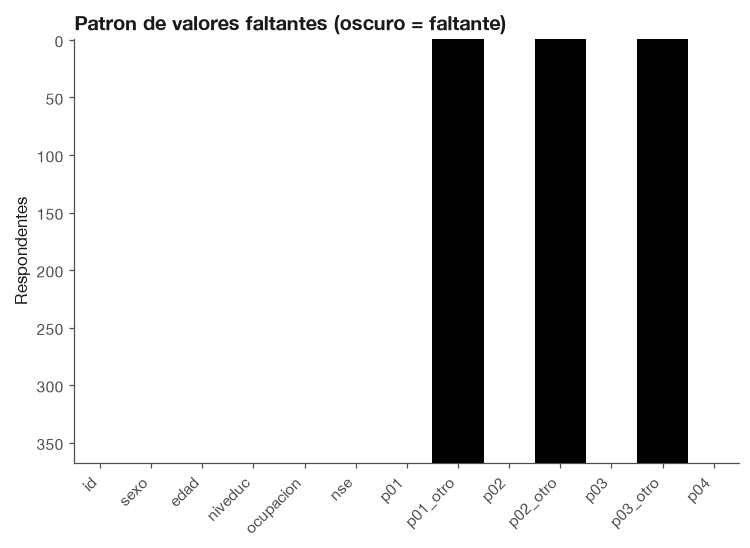

In [23]:
ax = missingness_heatmap(dfpymes)
save_fig(ax, "pymes_missingness_heatmap.png", subdir="pymes")

**Interpretacion (Hallazgo 11):** el patron de valores faltantes es **binario y
estructural**, no aleatorio: las 10 columnas de identificacion, demografia y respuesta cerrada
(`id`, `sexo`, `edad`, `niveduc`, `ocupacion`, `nse`, `p01`–`p04`) tienen **0% de datos
faltantes**, mientras que las 3 columnas de texto libre "otro" (`p01_otro`, `p02_otro`,
`p03_otro`) estan **100% vacias** porque ningun respondente eligio la opcion abierta en esas
preguntas. En el mapa de calor esto se ve como bandas completamente claras (variables completas)
y completamente oscuras (las 3 columnas "otro"), sin un patron intermedio de faltantes
parciales — es decir, no hay evidencia de abandono de encuesta ni de no-respuesta selectiva
dentro de las variables que si se usan en este analisis.

## 6. Resumen de hallazgos clave

1. **Muestra:** 368 dueños/as de PyMEs, sin valores faltantes en las variables demograficas ni
   en las 4 preguntas cerradas de negocio; solo los 3 campos de texto libre "otro" estan vacios.
2. **Sexo:** casi equilibrado (52.2% femenino / 47.8% masculino).
3. **Edad:** sesgada a tramos maduros — 64.7% tiene 41 años o mas; el tramo `[18-30]` es
   minoritario (14.9%).
4. **Educacion:** mayoritariamente post-secundaria (70.7% con formacion tecnica o
   universitaria, completa o incompleta); la educacion solo basica es marginal.
5. **Ocupacion:** heterogenea, con 3 categorias fuera del orden jerarquico documentado
   (requieren definicion de negocio antes de tratarse como escala ordinal).
6. **NSE:** concentrado en el segmento medio (c2+c3 = 68.8%).
7. **p01 (tarea que mas tiempo consume):** sin cuello de botella dominante; "atender clientes"
   y "hacer publicidad" lideran mas cerca del 25-27% cada una.
8. **p02 (fuente de ayuda):** "familia o amigos" domina (51.4%); el apoyo institucional formal
   (SERCOTEC) es minimo (4.3%) — brecha de alcance institucional.
9. **p03 (barreras):** "falta de capital" es la barrera abrumadoramente principal (60.3%),
   muy por delante de falta de clientes, tiempo o conocimiento.
10. **p04 (tiempo dispuesto a aprender):** alta disposicion — 94.3% dedicaria al menos algo de
    tiempo semanal a aprender herramientas digitales.
11. **Valores faltantes:** patron estructural y binario (0% o 100%), sin evidencia de
    no-respuesta parcial en las variables de analisis.

**Proximos pasos (fuera de alcance de este notebook):** cruces demografia × respuesta
(`PIPELINE_PLAN.md`, Step 4) y pruebas de significancia estadistica (Step 5), replicando esta
misma estructura univariada para el dataset de Competentes (Step 3).